# NPZ ROC analysis with fixed threshold 0.5

This notebook reads saved `.npz` prediction files, plots seed-wise ROC curves with a min--max band and mean ROC curve, and reports final Accuracy/F1 using fixed threshold `T=0.5`.

No threshold is selected from LOSO test predictions. Figures are displayed only and are not saved.

In [56]:
# ============================================================
# Notebook directory
# ============================================================
import os

os.chdir("/notebooks")
print("Current directory:",os.getcwd())

Current directory: /notebooks


In [57]:
# ============================================================
# Imports and settings
# ============================================================
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import roc_curve,auc,accuracy_score,f1_score,confusion_matrix

EXPERIMENT      = "SIMPLE"
FIXED_THRESHOLD = 0.5

# Added EDA+PPG so that MoEVAE results are read, plotted, and exported.
MODALITIES = ["EDA","PPG","TEXT","EDA+TEXT","PPG+TEXT"]
TASKS      = ["AROUSAL","VALENCE","STIMULUS-LABEL"]

OUTPUT_DIR = Path("output")
TABLE_DIR  = OUTPUT_DIR/"tables_fixed_threshold"
TABLE_DIR.mkdir(parents=True,exist_ok=True)

MEAN_FPR = np.linspace(0,1,101)

TASK_DISPLAY = {
    "AROUSAL":r"$\mathtt{arousal\_category}$",
    "VALENCE":r"$\mathtt{valence\_category}$",
    "STIMULUS-LABEL":r"$\mathtt{stimulus}$-$\mathtt{label}$",
}

TASK_TABLE_NAME = {
    "AROUSAL":r"\texttt{arousal\_category}",
    "VALENCE":r"\texttt{valence\_category}",
    "STIMULUS-LABEL":r"\texttt{stimulus-label}",
}

MODEL_ORDER_BY_MODALITY = {
    "EDA":["MLP","VAE"],
    "PPG":["MLP","VAE"],
    "TEXT":["MLP","VAE"],
    "EDA+TEXT":["MoEVAE","PoEVAE"],
    "PPG+TEXT":["MoEVAE","PoEVAE"],
}


In [58]:
# ============================================================
# Helper functions: file parsing and NPZ reading
# ============================================================
def normalize_model_name(model_name,modality=None):
    model_name = str(model_name).strip()
    modality   = str(modality).strip().upper() if modality is not None else None

    model_key = model_name.upper().replace("_","-").replace(" ","")

    if model_key in ["MLP","MLPCLASSIFIER","MLP-CLASSIFIER"]:
        return "MLP"

    if model_key in ["DISTILLBERT+PROJ128","DISTILBERT+PROJ128","DISTILLBERT-PROJ128"]:
        return "MLP"

    if model_key in ["VAE","VAECLASSIFIER","VAE-CLASSIFIER"]:
        if modality=="TEXT":
            return "VAE"
        return "VAE"

    if model_key in ["MOEVAE","MOE-VAE","MOEVAECLASSIFIER","MOEVAE-CLASSIFIER","MOE-VAE-CLASSIFIER"]:
        if modality=="TEXT":
            return "MoEVAE"
        return "MoEVAE"
    
    if model_key in ["PoEVAE"]:
        if modality=="TEXT":
            return "PoEVAE"
        return "PoEVAE"

    return model_name


def normalize_task_name(task_name):
    task_name = str(task_name).strip()
    task_key  = task_name.upper().replace("_","-")

    if "AROUSAL" in task_key:
        return "AROUSAL"
    if "VALENCE" in task_key:
        return "VALENCE"
    if "STIMULUS" in task_key or "TASKWISE" in task_key:
        return "STIMULUS-LABEL"

    return task_name


def normalize_modality_name(modality):
    modality = str(modality).strip().upper().replace("_","+")

    pair_aliases = {
        "EDA+PPG":"EDA+PPG",
        "PPG+EDA":"EDA+PPG",
        "EDA+TEXT":"EDA+TEXT",
        "TEXT+EDA":"EDA+TEXT",
        "PPG+TEXT":"PPG+TEXT",
        "TEXT+PPG":"PPG+TEXT",
    }

    return pair_aliases.get(modality,modality)


def parse_prediction_file(file_name):
    base = Path(file_name).name
    base = base.replace("-loso_predictions.npz","")
    base = base.replace("_loso_predictions.npz","")
    base = base.replace(".npz","")

    parts = base.split("-")

    raw_model = parts[0]

    if parts[-1].upper() in ["SIMPLE","SMOTE"]:
        experiment = parts[-1].upper()
        body_parts = parts[1:-1]
    else:
        experiment = "SIMPLE"
        body_parts = parts[1:]

    if len(body_parts)==0:
        raise ValueError(f"Cannot parse modality/task from file name: {file_name}")

    # Supports both MoEVAE-EDA+PPG-AROUSAL-SIMPLE.npz and MoEVAE-EDA-PPG-AROUSAL-SIMPLE.npz
    first = body_parts[0].upper().replace("_","+")
    second = body_parts[1].upper().replace("_","+") if len(body_parts)>1 else ""

    if first in ["EDA+PPG","PPG+EDA","EDA+TEXT","TEXT+EDA","PPG+TEXT","TEXT+PPG"]:
        modality = normalize_modality_name(first)
        task_parts = body_parts[1:]
    elif first in ["EDA","PPG","TEXT"] and second in ["EDA","PPG","TEXT"]:
        modality = normalize_modality_name(first+"+"+second)
        task_parts = body_parts[2:]
    else:
        modality = normalize_modality_name(first)
        task_parts = body_parts[1:]

    task  = normalize_task_name("-".join(task_parts))
    model = normalize_model_name(raw_model,modality=modality)

    return {"raw_model":raw_model,"model":model,"modality":modality,"task":task,"experiment":experiment}


def repeat_or_values(data,key,n,default=np.nan):
    if key not in data.files:
        return np.repeat(default,n)

    values = data[key]

    if np.ndim(values)==0:
        return np.repeat(values.item(),n)
    if len(values)==1 and n>1:
        return np.repeat(values[0],n)

    return values


def get_gt(data):
    if "gt_class" in data.files:
        gt = data["gt_class"]
    elif "gt" in data.files:
        gt = data["gt"]
    elif "y_true" in data.files:
        gt = data["y_true"]
    else:
        raise KeyError("No ground-truth key found. Expected one of: gt_class, gt, y_true")

    gt = np.asarray(gt)

    if gt.ndim==2 and gt.shape[1]>1:
        gt = np.argmax(gt,axis=1)
    elif gt.ndim==2 and gt.shape[1]==1:
        gt = gt[:,0]

    return gt.astype(int).reshape(-1)


def get_pred_proba(data):
    if "pred_proba" in data.files:
        pred_proba = data["pred_proba"]
    elif "pred_probs" in data.files:
        pred_proba = data["pred_probs"]
    elif "y_proba" in data.files:
        pred_proba = data["y_proba"]
    elif "probs" in data.files:
        pred_proba = data["probs"]
    elif "probability" in data.files:
        pred_proba = data["probability"]
    elif "prob_vector" in data.files:
        pred_proba = data["prob_vector"]
    else:
        raise KeyError("No probability key found. Expected pred_proba/pred_probs/y_proba/probs/probability/prob_vector")

    pred_proba = np.asarray(pred_proba)

    if pred_proba.ndim==2 and pred_proba.shape[1]>=2:
        pred_proba = pred_proba[:,1]
    elif pred_proba.ndim==2 and pred_proba.shape[1]==1:
        pred_proba = pred_proba[:,0]

    return pred_proba.astype(float).reshape(-1)


def clean_sample_id(x):
    x = str(x)
    if x.endswith(".0"):
        x = x[:-2]
    return x


In [59]:
# ============================================================
# Helper functions: ROC and fixed-threshold metrics
# ============================================================
def get_seedwise_df(df_exp):
    df_exp = df_exp.copy()

    df_exp["gt"]         = df_exp["gt"].astype(int)
    df_exp["pred_proba"] = df_exp["pred_proba"].astype(float)
    df_exp["seed"]       = df_exp["seed"].astype(int)

    df_exp = df_exp.groupby(["seed","sample_id"],as_index=False).agg(
        gt=("gt","first"),
        pred_proba=("pred_proba","mean"),
    )

    return df_exp


def get_seed_roc(y_true,y_score):
    fpr_raw,tpr_raw,thresholds_raw = roc_curve(y_true,y_score)
    seed_auc = auc(fpr_raw,tpr_raw)

    roc_df = pd.DataFrame({"fpr":fpr_raw,"tpr":tpr_raw})
    roc_df = roc_df.sort_values(["fpr","tpr"],ascending=[True,False]).drop_duplicates("fpr",keep="first").sort_values("fpr")

    fpr = roc_df["fpr"].values
    tpr = roc_df["tpr"].values

    interp_tpr     = np.interp(MEAN_FPR,fpr,tpr)
    interp_tpr[0]  = 0.0
    interp_tpr[-1] = 1.0

    return fpr_raw,tpr_raw,thresholds_raw,interp_tpr,seed_auc


def fixed_threshold_tpr_fpr(y_true,y_score,threshold=0.5):
    y_pred = (y_score>=threshold).astype(int)
    tn,fp,fn,tp = confusion_matrix(y_true,y_pred,labels=[0,1]).ravel()

    tpr = tp/(tp+fn) if (tp+fn)>0 else np.nan
    fpr = fp/(fp+tn) if (fp+tn)>0 else np.nan

    return tpr,fpr


def compute_mean_roc_fixed_threshold(df_exp,threshold=0.5):
    df_exp = get_seedwise_df(df_exp)

    seed_roc_rows    = []
    seed_metric_rows = []

    interp_tprs = []
    seed_aucs   = []
    fixed_tprs  = []
    fixed_fprs  = []

    for seed,seed_df in df_exp.groupby("seed"):
        y_true  = seed_df["gt"].values
        y_score = seed_df["pred_proba"].values

        if len(np.unique(y_true))<2:
            continue

        fpr,tpr,thresholds,interp_tpr,seed_auc = get_seed_roc(y_true,y_score)

        interp_tprs.append(interp_tpr)
        seed_aucs.append(seed_auc)

        y_pred = (y_score>=threshold).astype(int)
        fixed_tpr,fixed_fpr = fixed_threshold_tpr_fpr(y_true,y_score,threshold=threshold)

        fixed_tprs.append(fixed_tpr)
        fixed_fprs.append(fixed_fpr)

        seed_roc_rows.append({"seed":seed,"fpr":fpr,"tpr":tpr,"thresholds":thresholds,"auc":seed_auc})
        seed_metric_rows.append({
            "seed":seed,
            "threshold":threshold,
            "accuracy":accuracy_score(y_true,y_pred),
            "f1":f1_score(y_true,y_pred,zero_division=0),
            "fixed_tpr":fixed_tpr,
            "fixed_fpr":fixed_fpr,
        })

    if len(interp_tprs)==0:
        return None

    interp_tprs = np.asarray(interp_tprs)

    return {
        "seed_roc_rows":seed_roc_rows,
        "seed_metric_rows":seed_metric_rows,
        "mean_fpr":MEAN_FPR,
        "mean_tpr":np.mean(interp_tprs,axis=0),
        "min_tpr":np.min(interp_tprs,axis=0),
        "max_tpr":np.max(interp_tprs,axis=0),
        "threshold":threshold,
        "fixed_tpr":np.nanmean(fixed_tprs),
        "fixed_fpr":np.nanmean(fixed_fprs),
        "mean_auc":np.mean(seed_aucs),
        "std_auc":np.std(seed_aucs),
    }


def format_mean_std(mean_value,std_value):
    if pd.isna(mean_value):
        return "-"
    if pd.isna(std_value):
        std_value = 0.0
    return f"{mean_value:.3f} ± {std_value:.3f}"

Saved figure: thesis/figures/roc_grouped_EDA.png


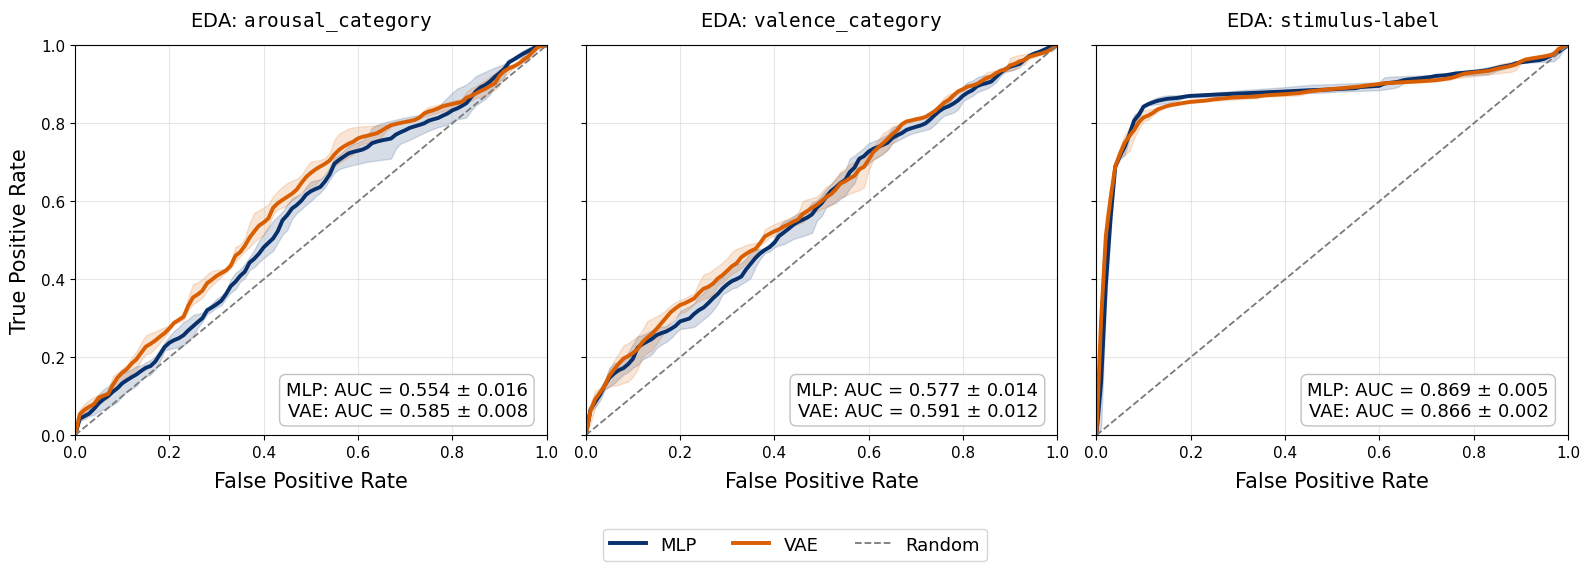

Saved figure: thesis/figures/roc_grouped_PPG.png


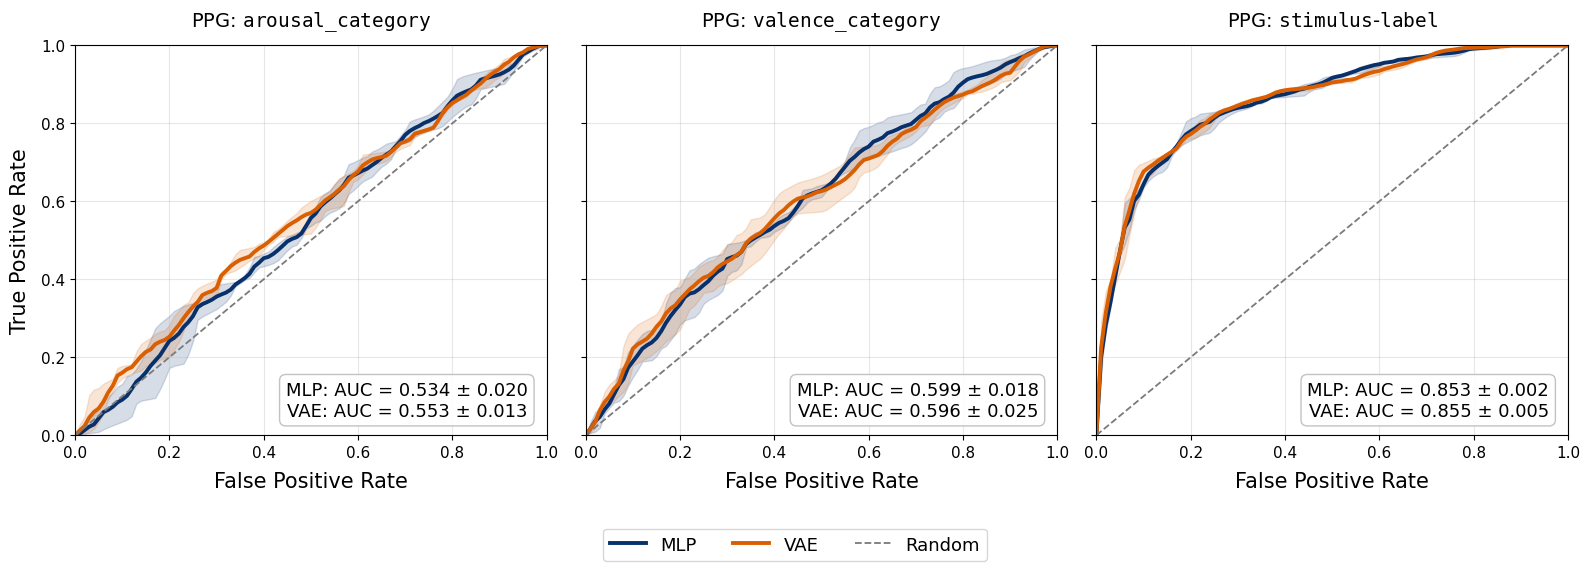

Saved figure: thesis/figures/roc_grouped_TEXT.png


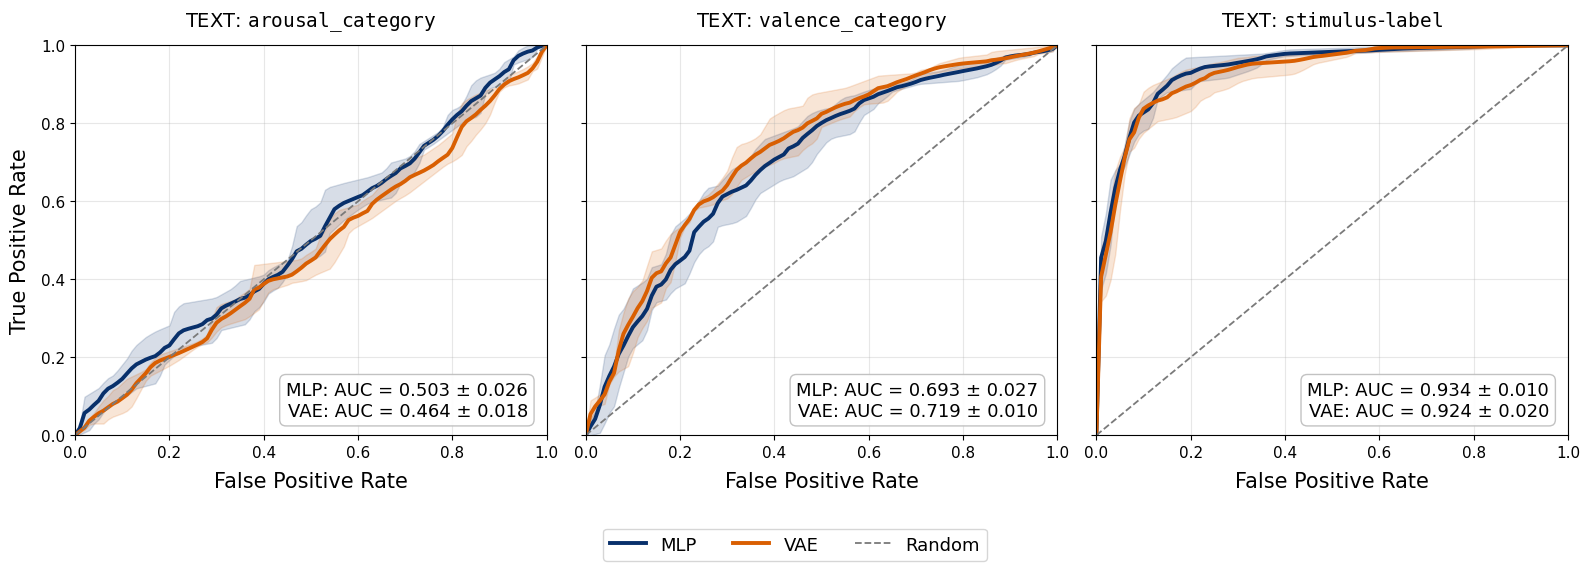

Saved figure: thesis/figures/roc_grouped_EDA_TEXT.png


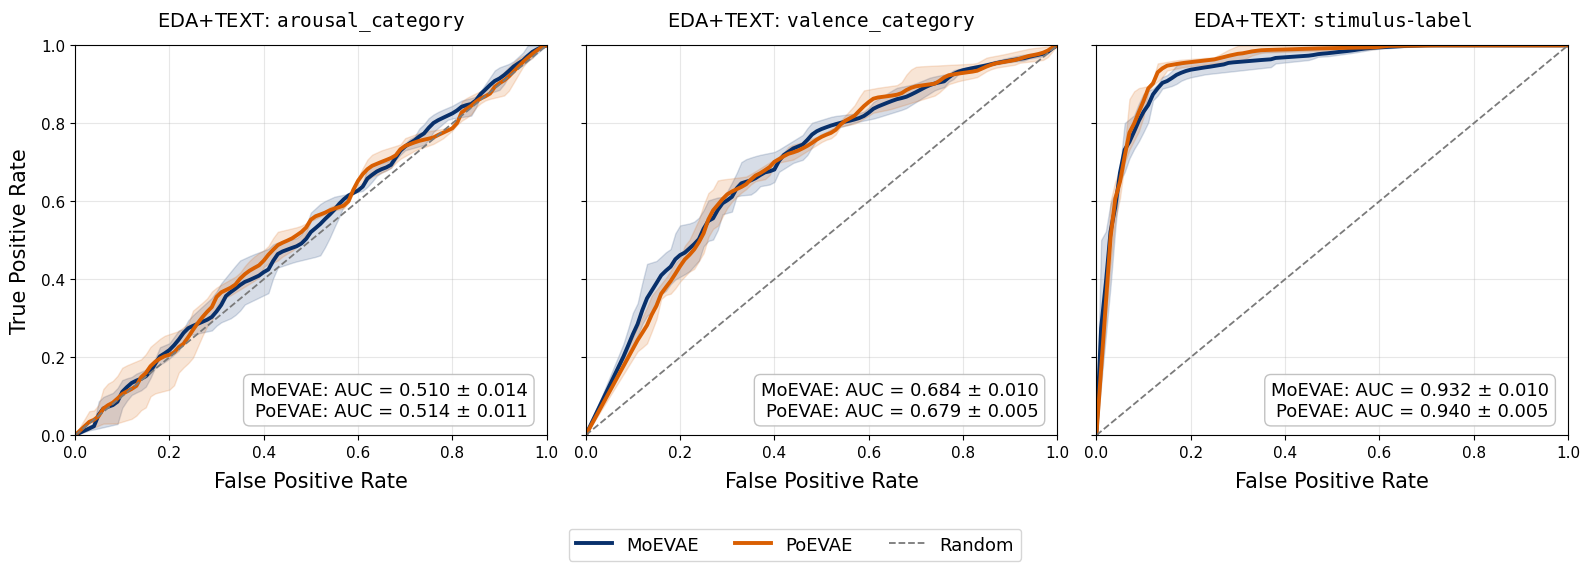

Saved figure: thesis/figures/roc_grouped_PPG_TEXT.png


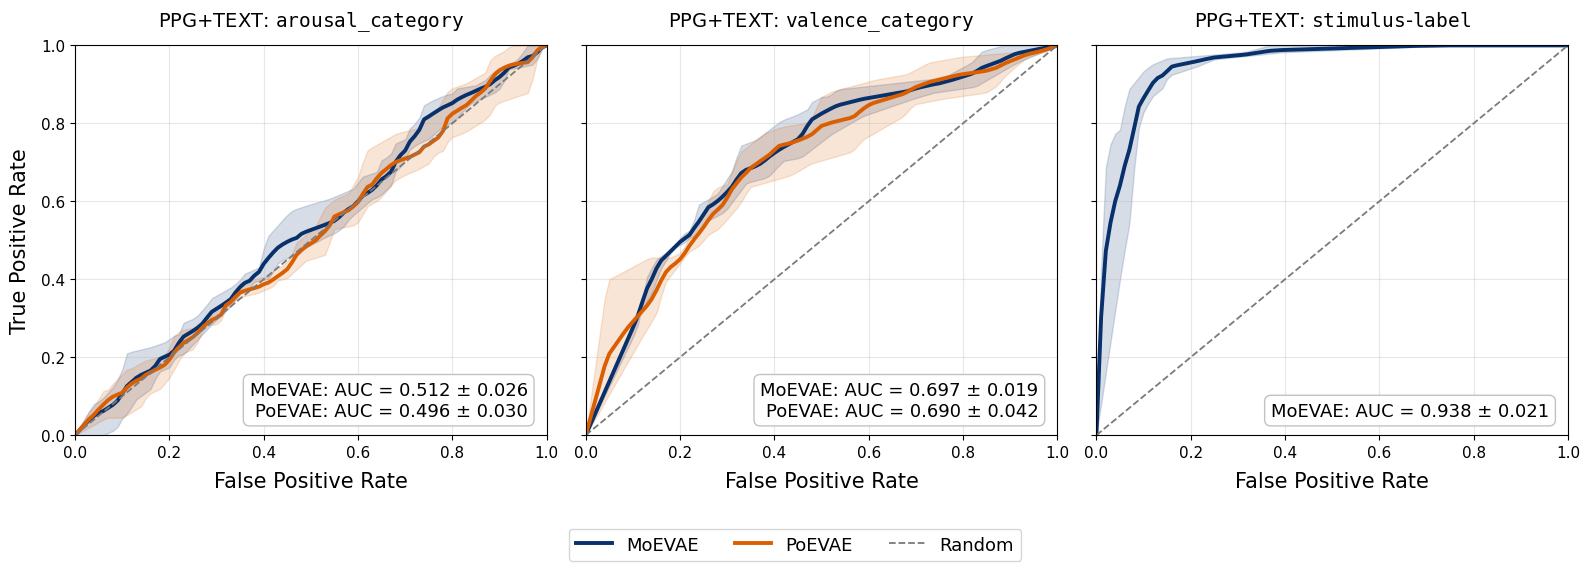

In [60]:
# ============================================================
# Run analysis and display grouped ROC plots
# One subplot per task; models are grouped inside each subplot.
# Fixed threshold 0.5 is used for Accuracy and F1.
# Figures are displayed and saved.
# ============================================================

from pathlib import Path
import re

seed_results_rows = []
summary_rows      = []

SHOW_SEED_ROCS        = False
SHOW_SEED_BAND        = True
SHOW_THRESHOLD_POINTS = False
SAVE_FIGURES          = True

FIGURE_DIR = Path("thesis/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_COLORS = [
    "#08306B",  # dark navy blue
    "#D95F02",  # burnt orange
]

NOTE_COLOR = "#666666"

TITLE_SIZE     = 16
SUBTITLE_SIZE  = 14
LABEL_SIZE     = 15
TICK_SIZE      = 11
AUC_SIZE       = 13
LEGEND_SIZE    = 13
NOTE_SIZE      = 11
LINE_WIDTH     = 2.8
MARKER_SIZE    = 58

for modality in MODALITIES:
    models_for_modality = MODEL_ORDER_BY_MODALITY[modality]

    fig,axes = plt.subplots(
        1,
        len(TASKS),
        figsize=(16,6.4),
        sharex=True,
        sharey=True,
    )

    axes = np.atleast_1d(axes)

    for col_i,task in enumerate(TASKS):
        ax = axes[col_i]
        task_name = TASK_DISPLAY.get(task,task)
        auc_lines = []
        plotted_any = False

        for model_i,model in enumerate(models_for_modality):
            model_color = MODEL_COLORS[model_i % len(MODEL_COLORS)]

            df_exp = pred_df[
                pred_df["modality"].eq(modality)
                & pred_df["model"].eq(model)
                & pred_df["task"].eq(task)
            ].copy()

            model_name = model

            if len(df_exp)==0:
                continue

            result = compute_mean_roc_fixed_threshold(df_exp,threshold=FIXED_THRESHOLD)

            if result is None:
                continue

            plotted_any = True

            if SHOW_SEED_ROCS:
                for seed_roc in result["seed_roc_rows"]:
                    ax.plot(
                        seed_roc["fpr"],
                        seed_roc["tpr"],
                        lw=1.0,
                        alpha=0.30,
                        color=model_color,
                    )

            if SHOW_SEED_BAND:
                ax.fill_between(
                    result["mean_fpr"],
                    result["min_tpr"],
                    result["max_tpr"],
                    alpha=0.16,
                    color=model_color,
                )

            ax.plot(
                result["mean_fpr"],
                result["mean_tpr"],
                lw=LINE_WIDTH,
                color=model_color,
                label=f"{model_name}",
            )

            seed_metrics_df = pd.DataFrame(result["seed_metric_rows"])

            if SHOW_THRESHOLD_POINTS:
                fixed_fpr_mean = seed_metrics_df["fixed_fpr"].mean()
                fixed_tpr_mean = seed_metrics_df["fixed_tpr"].mean()

                ax.scatter(
                    fixed_fpr_mean,
                    fixed_tpr_mean,
                    s=MARKER_SIZE,
                    color=model_color,
                    edgecolor="black",
                    linewidth=0.8,
                    zorder=5,
                    label=f"{model_name} at t={FIXED_THRESHOLD}",
                )

            auc_lines.append(
                f"{model_name}: AUC = {result['mean_auc']:.3f} ± {result['std_auc']:.3f}"
            )

            for seed_metric in result["seed_metric_rows"]:
                seed_auc = [
                    x["auc"] for x in result["seed_roc_rows"]
                    if x["seed"]==seed_metric["seed"]
                ][0]

                seed_results_rows.append({
                    "modality":modality,
                    "model":model,
                    "model_name":model_name,
                    "task":task,
                    "target":TASK_TABLE_NAME.get(task,task),
                    "seed":seed_metric["seed"],
                    "threshold":FIXED_THRESHOLD,
                    "accuracy":seed_metric["accuracy"],
                    "f1":seed_metric["f1"],
                    "auc":seed_auc,
                    "fixed_tpr":seed_metric["fixed_tpr"],
                    "fixed_fpr":seed_metric["fixed_fpr"],
                })

            summary_rows.append({
                "Modality":modality,
                "Model":model_name,
                "Target":TASK_TABLE_NAME.get(task,task),
                "Threshold_value":FIXED_THRESHOLD,
                "Accuracy_mean":seed_metrics_df["accuracy"].mean(),
                "Accuracy_std":seed_metrics_df["accuracy"].std(ddof=0),
                "F1_mean":seed_metrics_df["f1"].mean(),
                "F1_std":seed_metrics_df["f1"].std(ddof=0),
                "AUC_mean":result["mean_auc"],
                "AUC_std":result["std_auc"],
                "TPR_mean":seed_metrics_df["fixed_tpr"].mean(),
                "TPR_std":seed_metrics_df["fixed_tpr"].std(ddof=0),
                "FPR_mean":seed_metrics_df["fixed_fpr"].mean(),
                "FPR_std":seed_metrics_df["fixed_fpr"].std(ddof=0),
            })

        ax.plot(
            [0,1],
            [0,1],
            linestyle="--",
            lw=1.3,
            color="#7A7A7A",
            label="Random",
        )

        if plotted_any:
            ax.text(
                0.96,
                0.04,
                "\n".join(auc_lines),
                transform=ax.transAxes,
                fontsize=AUC_SIZE,
                ha="right",
                va="bottom",
                bbox=dict(
                    boxstyle="round,pad=0.35",
                    facecolor="white",
                    edgecolor="#BDBDBD",
                    alpha=0.92,
                ),
            )
        else:
            ax.text(
                0.5,
                0.5,
                "No ROC data",
                ha="center",
                va="center",
                fontsize=AUC_SIZE,
                transform=ax.transAxes,
            )

        ax.set_title(f"{modality}: {task_name}", fontsize=SUBTITLE_SIZE, pad=14)
        ax.set_xlabel("False Positive Rate", fontsize=LABEL_SIZE, labelpad=8)

        if col_i == 0:
            ax.set_ylabel("True Positive Rate", fontsize=LABEL_SIZE, labelpad=8)
        else:
            ax.set_ylabel("")

        ax.set_xlim(0,1)
        ax.set_ylim(0,1)
        ax.tick_params(axis="both", labelsize=TICK_SIZE)
        ax.grid(alpha=0.30)

    handles,labels = [],[]

    for ax in axes.flatten():
        h,l = ax.get_legend_handles_labels()
        for handle,label in zip(h,l):
            if label not in labels:
                handles.append(handle)
                labels.append(label)

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=min(len(labels),5),
        fontsize=LEGEND_SIZE,
        frameon=True,
        bbox_to_anchor=(0.5,0.04),
    )


    plt.tight_layout(rect=[0,0.14,1,0.94])

    if SAVE_FIGURES:
        safe_modality = re.sub(r"[^A-Za-z0-9_]+","_",str(modality)).strip("_")

        png_path = FIGURE_DIR / f"roc_grouped_{safe_modality}.png"
        pdf_path = FIGURE_DIR / f"roc_grouped_{safe_modality}.pdf"

        fig.savefig(
            png_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )

        fig.savefig(
            pdf_path,
            bbox_inches="tight",
            facecolor="white",
        )

        print(f"Saved figure: {png_path}")
        

    plt.show()

In [61]:
# ============================================================
# Read all NPZ prediction files
# ============================================================
npz_files = sorted(glob.glob("output/*.npz"))

print("Number of npz files found:",len(npz_files))

if len(npz_files)==0:
    raise FileNotFoundError("No .npz files found in output/*.npz")

all_rows = []

for file_path in npz_files:
    file_name  = Path(file_path).name
    data       = np.load(file_path,allow_pickle=True)
    gt         = get_gt(data)
    pred_proba = get_pred_proba(data)
    n          = len(gt)

    if len(pred_proba)!=n:
        raise ValueError(f"Length mismatch in {file_name}: len(gt)={n}, len(pred_proba)={len(pred_proba)}")

    meta = parse_prediction_file(file_name)

    sample_id = repeat_or_values(data,"sample_id",n,default="")
    sample_id = np.array([clean_sample_id(x) for x in sample_id])

    if np.all(sample_id==""):
        sample_id = np.array([f"{file_name}_{i}" for i in range(n)])

    row_df = pd.DataFrame({
        "file":np.repeat(file_name,n),
        "raw_model":np.repeat(meta["raw_model"],n),
        "model":np.repeat(meta["model"],n),
        "modality":np.repeat(meta["modality"],n),
        "task":np.repeat(meta["task"],n),
        "experiment":np.repeat(meta["experiment"],n),
        "sample_id":sample_id,
        "gt":gt,
        "pred_proba":pred_proba,
        "seed":repeat_or_values(data,"seed",n),
        "fold":repeat_or_values(data,"fold",n),
        "pid":repeat_or_values(data,"pid",n),
    })

    all_rows.append(row_df)

pred_df = pd.concat(all_rows,ignore_index=True)

print("Available files before filtering:")
display(pred_df[["file","raw_model","model","modality","task","experiment"]].drop_duplicates().sort_values(["modality","task","model"]))

pred_df = pred_df[
    pred_df["experiment"].eq(EXPERIMENT)
    & pred_df["modality"].isin(MODALITIES)
    & pred_df["task"].isin(TASKS)
].copy()

# keep only models included in plotting/table order
valid_models = []
for model_list in MODEL_ORDER_BY_MODALITY.values():
    valid_models.extend(model_list)
valid_models = sorted(set(valid_models))

pred_df = pred_df[pred_df["model"].isin(valid_models)].copy()

print("Prediction dataframe after filtering:")
display(pred_df.head())

print("Available files after filtering:")
display(pred_df[["file","raw_model","model","modality","task","experiment"]].drop_duplicates().sort_values(["modality","task","model"]))


Number of npz files found: 31
Available files before filtering:


,file,raw_model,model,modality,task,experiment
2880,MLP-EDA-AROUSAL-SIMPLE-predictions.npz,MLP,MLP,EDA,AROUSAL,SIMPLE
19089,VAE-EDA-AROUSAL-SIMPLE-predictions.npz,VAE,VAE,EDA,AROUSAL,SIMPLE
3879,MLP-EDA-STIMULUS-LABEL-SIMPLE-predictions.npz,MLP,MLP,EDA,STIMULUS-LABEL,SIMPLE
20088,VAE-EDA-STIMULUS-LABEL-SIMPLE-predictions.npz,VAE,VAE,EDA,STIMULUS-LABEL,SIMPLE
4878,MLP-EDA-VALENCE-SIMPLE-predictions.npz,MLP,MLP,EDA,VALENCE,SIMPLE
21087,VAE-EDA-VALENCE-SIMPLE-predictions.npz,VAE,VAE,EDA,VALENCE,SIMPLE
8874,MoEVAE-EDA+PPG-AROUSAL-SIMPLE-predictions.npz,MoEVAE,MoEVAE,EDA+PPG,AROUSAL,SIMPLE
9873,MoEVAE-EDA+TEXT-AROUSAL-SIMPLE-predictions.npz,MoEVAE,MoEVAE,EDA+TEXT,AROUSAL,SIMPLE
14481,PoEVAE-EDA+TEXT-AROUSAL-SIMPLE-predictions.npz,PoEVAE,PoEVAE,EDA+TEXT,AROUSAL,SIMPLE
10833,MoEVAE-EDA+TEXT-STIMULUS-LABEL-SIMPLE-predicti...,MoEVAE,MoEVAE,EDA+TEXT,STIMULUS-LABEL,SIMPLE


Prediction dataframe after filtering:


,file,raw_model,model,modality,task,experiment,sample_id,gt,pred_proba,seed,fold,pid
0,DISTILLBERT+Proj128-TEXT-AROUSAL-SIMPLE-predic...,DISTILLBERT+Proj128,MLP,TEXT,AROUSAL,SIMPLE,5_1,0,0.425032,42,1,"5,8,16,20,28,29,33,39"
1,DISTILLBERT+Proj128-TEXT-AROUSAL-SIMPLE-predic...,DISTILLBERT+Proj128,MLP,TEXT,AROUSAL,SIMPLE,5_2,0,0.036479,42,1,"5,8,16,20,28,29,33,39"
2,DISTILLBERT+Proj128-TEXT-AROUSAL-SIMPLE-predic...,DISTILLBERT+Proj128,MLP,TEXT,AROUSAL,SIMPLE,5_3,0,0.003461,42,1,"5,8,16,20,28,29,33,39"
3,DISTILLBERT+Proj128-TEXT-AROUSAL-SIMPLE-predic...,DISTILLBERT+Proj128,MLP,TEXT,AROUSAL,SIMPLE,5_4,0,0.212653,42,1,"5,8,16,20,28,29,33,39"
4,DISTILLBERT+Proj128-TEXT-AROUSAL-SIMPLE-predic...,DISTILLBERT+Proj128,MLP,TEXT,AROUSAL,SIMPLE,5_5,0,0.619799,42,1,"5,8,16,20,28,29,33,39"


Available files after filtering:


,file,raw_model,model,modality,task,experiment
2880,MLP-EDA-AROUSAL-SIMPLE-predictions.npz,MLP,MLP,EDA,AROUSAL,SIMPLE
19089,VAE-EDA-AROUSAL-SIMPLE-predictions.npz,VAE,VAE,EDA,AROUSAL,SIMPLE
3879,MLP-EDA-STIMULUS-LABEL-SIMPLE-predictions.npz,MLP,MLP,EDA,STIMULUS-LABEL,SIMPLE
20088,VAE-EDA-STIMULUS-LABEL-SIMPLE-predictions.npz,VAE,VAE,EDA,STIMULUS-LABEL,SIMPLE
4878,MLP-EDA-VALENCE-SIMPLE-predictions.npz,MLP,MLP,EDA,VALENCE,SIMPLE
21087,VAE-EDA-VALENCE-SIMPLE-predictions.npz,VAE,VAE,EDA,VALENCE,SIMPLE
9873,MoEVAE-EDA+TEXT-AROUSAL-SIMPLE-predictions.npz,MoEVAE,MoEVAE,EDA+TEXT,AROUSAL,SIMPLE
14481,PoEVAE-EDA+TEXT-AROUSAL-SIMPLE-predictions.npz,PoEVAE,PoEVAE,EDA+TEXT,AROUSAL,SIMPLE
10833,MoEVAE-EDA+TEXT-STIMULUS-LABEL-SIMPLE-predicti...,MoEVAE,MoEVAE,EDA+TEXT,STIMULUS-LABEL,SIMPLE
15441,PoEVAE-EDA+TEXT-STIMULUS-LABEL-SIMPLE-predicti...,PoEVAE,PoEVAE,EDA+TEXT,STIMULUS-LABEL,SIMPLE


Saved figure: thesis/figures/roc_grouped_EDA.png


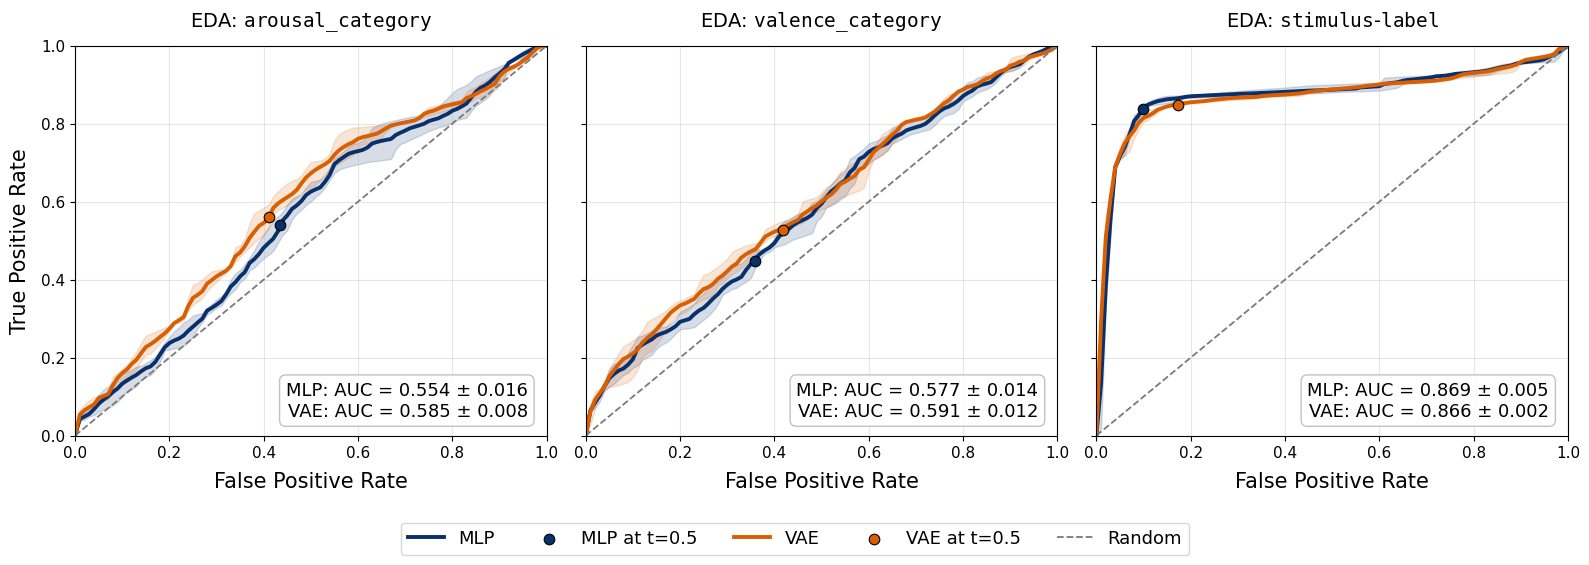

Saved figure: thesis/figures/roc_grouped_PPG.png


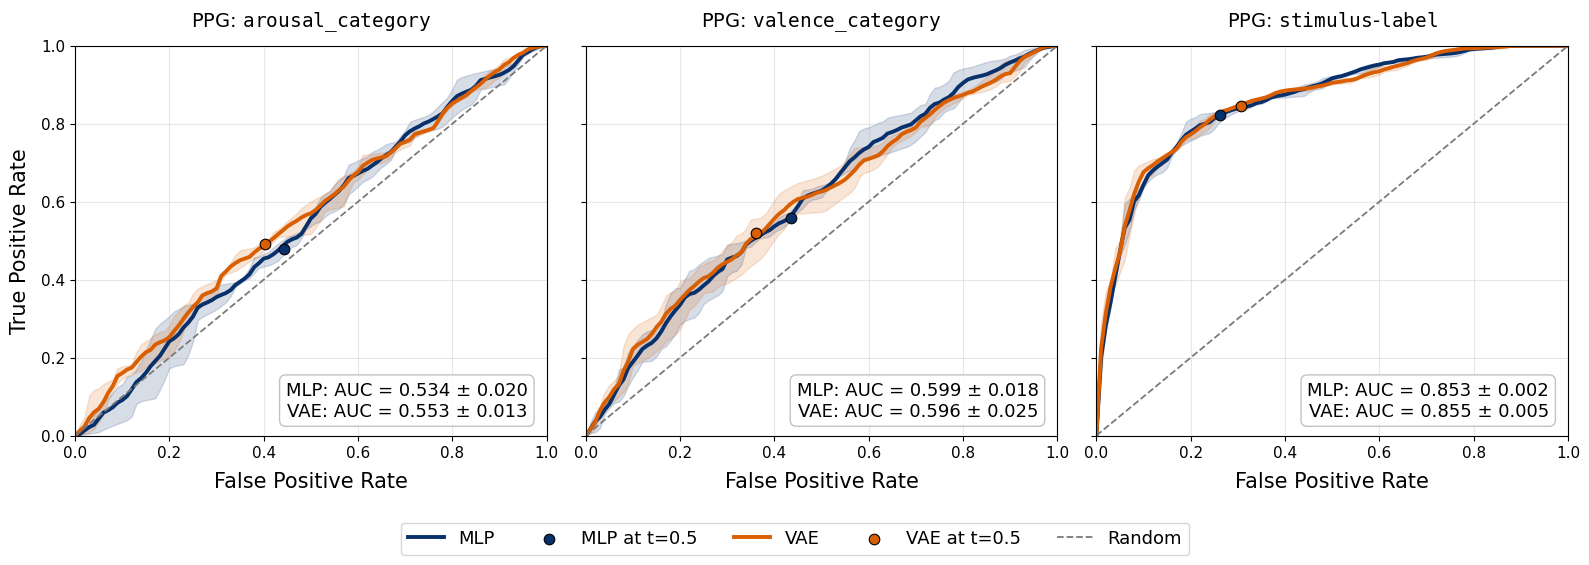

Saved figure: thesis/figures/roc_grouped_TEXT.png


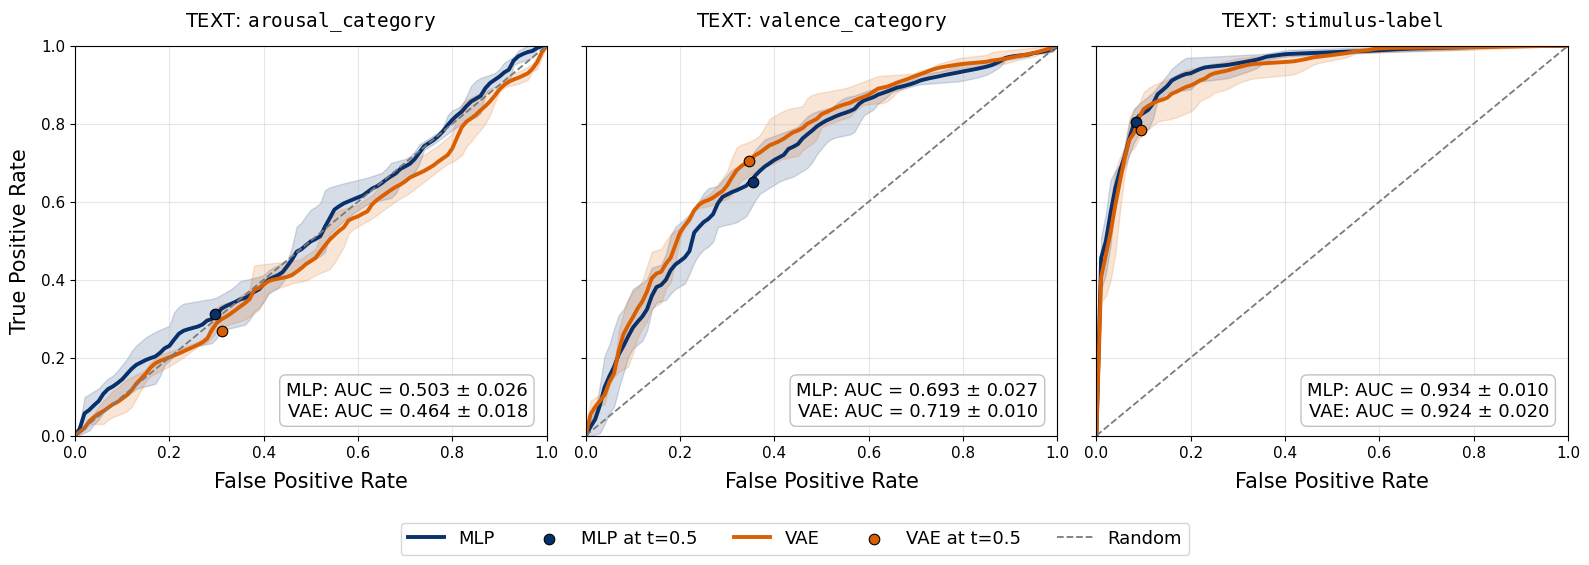

Saved figure: thesis/figures/roc_grouped_EDA_TEXT.png


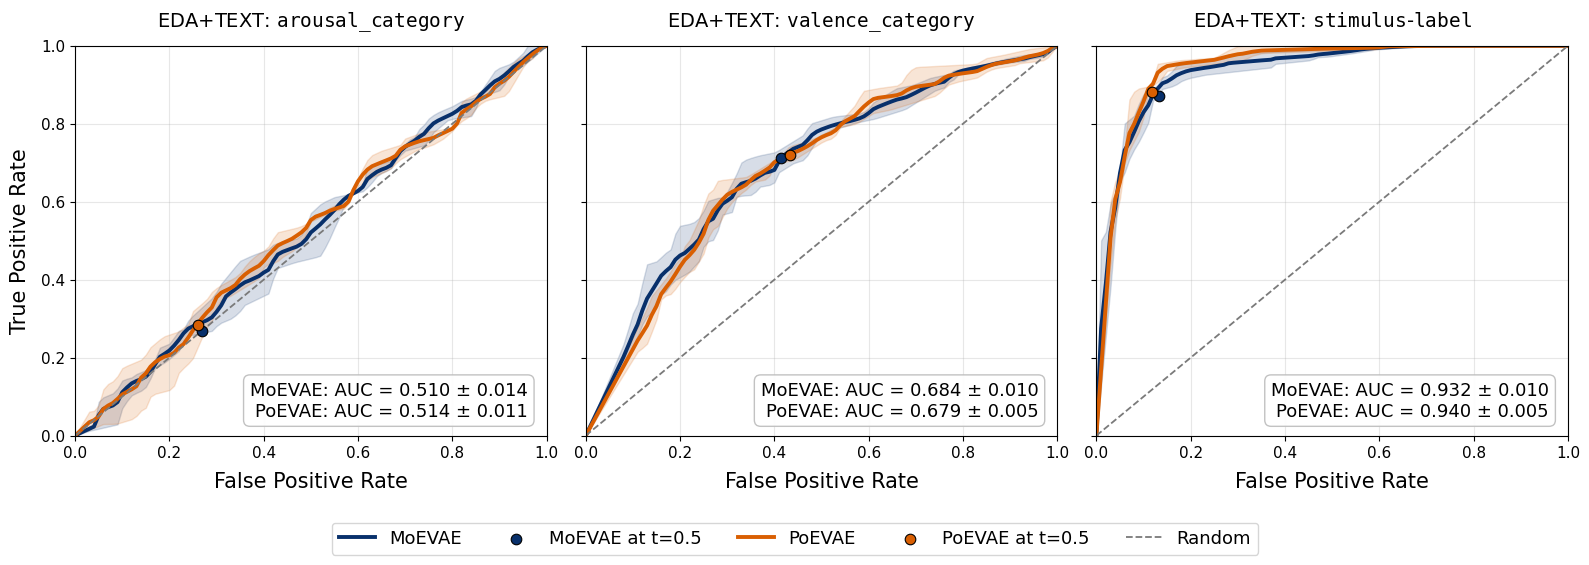

Saved figure: thesis/figures/roc_grouped_PPG_TEXT.png


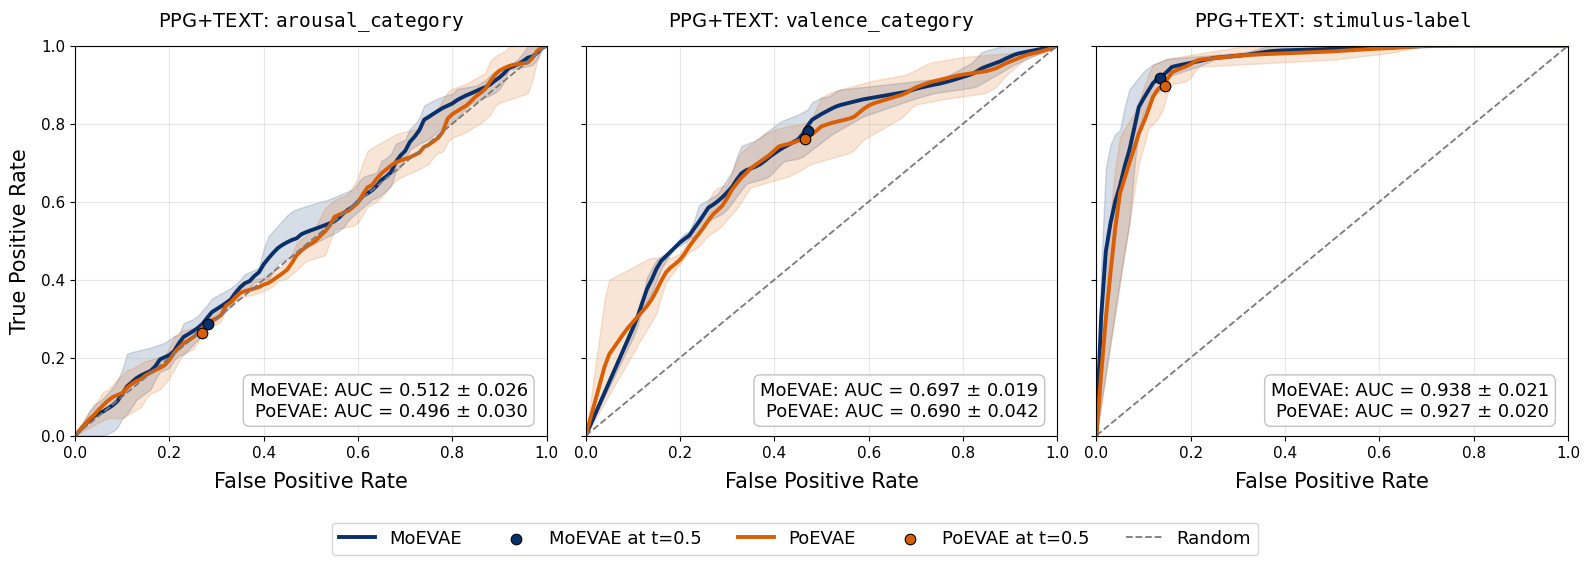

In [62]:
# ============================================================
# Run analysis and display grouped ROC plots
# One subplot per task; models are grouped inside each subplot.
# Fixed threshold 0.5 is used for Accuracy and F1.
# Figures are displayed and saved.
# ============================================================

from pathlib import Path
import re

seed_results_rows = []
summary_rows      = []

SHOW_SEED_ROCS            = False
SHOW_SEED_BAND            = True
SHOW_THRESHOLD_POINTS     = True
SHOW_THRESHOLD_DIRECTION  = False
SAVE_FIGURES              = True

# Save folder
FIGURE_DIR = Path("thesis/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Blue + opposite-of-blue color scheme
MODEL_COLORS = [
    "#08306B",  # dark navy blue
    "#D95F02",  # burnt orange
]

THRESHOLD_DIRECTION_COLOR = "#7A7A7A"

# Bigger thesis-friendly font sizes
TITLE_SIZE      = 16
SUBTITLE_SIZE   = 14
LABEL_SIZE      = 15
TICK_SIZE       = 11
AUC_SIZE        = 13
LEGEND_SIZE     = 13
DIRECTION_SIZE  = 10.5
LINE_WIDTH      = 2.8
MARKER_SIZE     = 58

for modality in MODALITIES:
    models_for_modality = MODEL_ORDER_BY_MODALITY[modality]

    fig,axes = plt.subplots(
        1,
        len(TASKS),
        figsize=(16,6.4),
        sharex=True,
        sharey=True,
    )

    axes = np.atleast_1d(axes)

    for col_i,task in enumerate(TASKS):
        ax = axes[col_i]
        task_name = TASK_DISPLAY.get(task,task)
        auc_lines = []
        plotted_any = False

        for model_i,model in enumerate(models_for_modality):
            model_color = MODEL_COLORS[model_i % len(MODEL_COLORS)]

            df_exp = pred_df[
                pred_df["modality"].eq(modality)
                & pred_df["model"].eq(model)
                & pred_df["task"].eq(task)
            ].copy()

            model_name = model

            if len(df_exp)==0:
                continue

            result = compute_mean_roc_fixed_threshold(df_exp,threshold=FIXED_THRESHOLD)

            if result is None:
                continue

            plotted_any = True

            if SHOW_SEED_ROCS:
                for seed_roc in result["seed_roc_rows"]:
                    ax.plot(
                        seed_roc["fpr"],
                        seed_roc["tpr"],
                        lw=1.0,
                        alpha=0.30,
                        color=model_color,
                    )

            if SHOW_SEED_BAND:
                ax.fill_between(
                    result["mean_fpr"],
                    result["min_tpr"],
                    result["max_tpr"],
                    alpha=0.16,
                    color=model_color,
                )

            # Mean ROC curve
            ax.plot(
                result["mean_fpr"],
                result["mean_tpr"],
                lw=LINE_WIDTH,
                color=model_color,
                label=f"{model_name}",
            )

            seed_metrics_df = pd.DataFrame(result["seed_metric_rows"])

            # Fixed threshold point
            if SHOW_THRESHOLD_POINTS:
                fixed_fpr_mean = seed_metrics_df["fixed_fpr"].mean()
                fixed_tpr_mean = seed_metrics_df["fixed_tpr"].mean()

                ax.scatter(
                    fixed_fpr_mean,
                    fixed_tpr_mean,
                    s=MARKER_SIZE,
                    color=model_color,
                    edgecolor="black",
                    linewidth=0.8,
                    zorder=5,
                    label=f"{model_name} at t={FIXED_THRESHOLD}",
                )

            auc_lines.append(
                f"{model_name}: AUC = {result['mean_auc']:.3f} ± {result['std_auc']:.3f}"
            )

            # Seed-wise metric rows
            for seed_metric in result["seed_metric_rows"]:
                seed_auc = [
                    x["auc"] for x in result["seed_roc_rows"]
                    if x["seed"]==seed_metric["seed"]
                ][0]

                seed_results_rows.append({
                    "modality":modality,
                    "model":model,
                    "model_name":model_name,
                    "task":task,
                    "target":TASK_TABLE_NAME.get(task,task),
                    "seed":seed_metric["seed"],
                    "threshold":FIXED_THRESHOLD,
                    "accuracy":seed_metric["accuracy"],
                    "f1":seed_metric["f1"],
                    "auc":seed_auc,
                    "fixed_tpr":seed_metric["fixed_tpr"],
                    "fixed_fpr":seed_metric["fixed_fpr"],
                })

            summary_rows.append({
                "Modality":modality,
                "Model":model_name,
                "Target":TASK_TABLE_NAME.get(task,task),
                "Threshold_value":FIXED_THRESHOLD,
                "Accuracy_mean":seed_metrics_df["accuracy"].mean(),
                "Accuracy_std":seed_metrics_df["accuracy"].std(ddof=0),
                "F1_mean":seed_metrics_df["f1"].mean(),
                "F1_std":seed_metrics_df["f1"].std(ddof=0),
                "AUC_mean":result["mean_auc"],
                "AUC_std":result["std_auc"],
                "TPR_mean":seed_metrics_df["fixed_tpr"].mean(),
                "TPR_std":seed_metrics_df["fixed_tpr"].std(ddof=0),
                "FPR_mean":seed_metrics_df["fixed_fpr"].mean(),
                "FPR_std":seed_metrics_df["fixed_fpr"].std(ddof=0),
            })

        # Random classifier line
        ax.plot(
            [0,1],
            [0,1],
            linestyle="--",
            lw=1.3,
            color="#7A7A7A",
            label="Random",
        )

        # AUC box at right-bottom
        if plotted_any:
            ax.text(
                0.96,
                0.04,
                "\n".join(auc_lines),
                transform=ax.transAxes,
                fontsize=AUC_SIZE,
                ha="right",
                va="bottom",
                bbox=dict(
                    boxstyle="round,pad=0.35",
                    facecolor="white",
                    edgecolor="#BDBDBD",
                    alpha=0.92,
                ),
            )
        else:
            ax.text(
                0.5,
                0.5,
                "No ROC data",
                ha="center",
                va="center",
                fontsize=AUC_SIZE,
                transform=ax.transAxes,
            )

        ax.set_title(f"{modality}: {task_name}", fontsize=SUBTITLE_SIZE, pad=14)
        ax.set_xlabel("False Positive Rate", fontsize=LABEL_SIZE, labelpad=8)

        if col_i == 0:
            ax.set_ylabel("True Positive Rate", fontsize=LABEL_SIZE, labelpad=8)
        else:
            ax.set_ylabel("")

        ax.set_xlim(0,1)
        ax.set_ylim(0,1)
        ax.tick_params(axis="both", labelsize=TICK_SIZE)
        ax.grid(alpha=0.30)

        # General direction of decreasing threshold
        if SHOW_THRESHOLD_DIRECTION:
            ax.annotate(
                "",
                xy=(0.76,0.91),
                xytext=(0.34,0.91),
                xycoords="axes fraction",
                arrowprops=dict(
                    arrowstyle="->",
                    color=THRESHOLD_DIRECTION_COLOR,
                    lw=1.4,
                ),
            )

            ax.text(
                0.55,
                0.94,
                "threshold decreases",
                transform=ax.transAxes,
                fontsize=DIRECTION_SIZE,
                ha="center",
                va="bottom",
                color=THRESHOLD_DIRECTION_COLOR,
                bbox=dict(
                    boxstyle="round,pad=0.20",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.75,
                ),
            )

    # Figure-level legend at bottom center
    handles,labels = [],[]

    for ax in axes.flatten():
        h,l = ax.get_legend_handles_labels()
        for handle,label in zip(h,l):
            if label not in labels:
                handles.append(handle)
                labels.append(label)

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=min(len(labels),5),
        fontsize=LEGEND_SIZE,
        frameon=True,
        bbox_to_anchor=(0.5,0.02),
    )

    plt.tight_layout(rect=[0,0.11,1,0.91])

    if SAVE_FIGURES:
        safe_modality = re.sub(r"[^A-Za-z0-9_]+","_",str(modality)).strip("_")

        png_path = FIGURE_DIR / f"roc_grouped_{safe_modality}.png"
        pdf_path = FIGURE_DIR / f"roc_grouped_{safe_modality}.pdf"

        fig.savefig(
            png_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )

    
        print(f"Saved figure: {png_path}")
    

    plt.show()

In [63]:
# ============================================================
# Build final results tables based on fixed threshold T=0.5
# ============================================================
seed_results_table = pd.DataFrame(seed_results_rows)
summary_raw_table  = pd.DataFrame(summary_rows)

summary_table = summary_raw_table.copy()
display(summary_table)

if "Threshold_value" not in summary_table.columns:
    summary_table["Threshold_value"] = FIXED_THRESHOLD

summary_table["Threshold"] = summary_table["Threshold_value"].map(lambda x:f"{float(x):.3f}")
summary_table["Accuracy"]  = summary_table.apply(lambda r:format_mean_std(r["Accuracy_mean"],r["Accuracy_std"]),axis=1)
summary_table["F1"]        = summary_table.apply(lambda r:format_mean_std(r["F1_mean"],r["F1_std"]),axis=1)
summary_table["AUC"]       = summary_table.apply(lambda r:format_mean_std(r["AUC_mean"],r["AUC_std"]),axis=1)

summary_table = summary_table[["Modality","Model","Target","Threshold","Accuracy","F1","AUC"]].copy()

wide_results_table = summary_table.pivot_table(
    index=["Modality","Model"],
    columns="Target",
    values=["Threshold","Accuracy","F1","AUC"],
    aggfunc="first",
)

wide_results_table.columns = [f"{metric}_{target}" for metric,target in wide_results_table.columns]
wide_results_table = wide_results_table.reset_index()

seed_results_path = TABLE_DIR/"npz_seedwise_results_fixed_threshold_0_5.csv"
summary_raw_path  = TABLE_DIR/"npz_summary_results_raw_fixed_threshold_0_5.csv"
summary_path      = TABLE_DIR/"npz_summary_results_fixed_threshold_0_5.csv"
wide_path         = TABLE_DIR/"npz_summary_results_wide_fixed_threshold_0_5.csv"
latex_path        = TABLE_DIR/"npz_summary_results_grouped_fixed_threshold_0_5.tex"

seed_results_table.to_csv(seed_results_path,index=False)
summary_raw_table.to_csv(summary_raw_path,index=False)
summary_table.to_csv(summary_path,index=False)
wide_results_table.to_csv(wide_path,index=False)

grouped_results_table = dataframe_to_latex(
    summary_table,
    latex_path,
    caption="Classification results using a fixed threshold of $T=0.5$ for each model and target label.",
    label="tab:results_grouped_fixed_threshold",
)

print("Saved tables:")
print(seed_results_path)
print(summary_raw_path)
print(summary_path)
print(wide_path)
print(latex_path)

print("\nSeed-wise results:")
display(seed_results_table)

print("\nFinal summary table:")
display(summary_table)

print("\nWide results table:")
display(wide_results_table)

print("\nGrouped LaTeX table preview:")
display(grouped_results_table)


,Modality,Model,Target,Threshold_value,Accuracy_mean,Accuracy_std,F1_mean,F1_std,AUC_mean,AUC_std,TPR_mean,TPR_std,FPR_mean,FPR_std
0,EDA,MLP,\texttt{arousal\_category},0.5,0.557558,0.010208,0.454662,0.029348,0.553913,0.016013,0.540936,0.053757,0.433790,0.019373
1,EDA,VAE,\texttt{arousal\_category},0.5,0.579580,0.012974,0.477588,0.000737,0.584929,0.008028,0.561404,0.018950,0.410959,0.029592
2,EDA,MLP,\texttt{valence\_category},0.5,0.524525,0.011056,0.533797,0.012898,0.577293,0.013842,0.448845,0.012993,0.358779,0.010796
3,EDA,VAE,\texttt{valence\_category},0.5,0.548549,0.007078,0.585693,0.008299,0.590746,0.011902,0.526403,0.019939,0.417303,0.041500
4,EDA,MLP,\texttt{stimulus-label},0.5,0.872873,0.001416,0.854163,0.002933,0.868615,0.005295,0.837838,0.011034,0.099099,0.006742
5,EDA,VAE,\texttt{stimulus-label},0.5,0.836837,0.007491,0.822296,0.006849,0.865924,0.002258,0.849099,0.003185,0.172973,0.013240
6,PPG,MLP,\texttt{arousal\_category},0.5,0.530531,0.009909,0.411574,0.010457,0.534193,0.020371,0.479532,0.010941,0.442922,0.009864
7,PPG,VAE,\texttt{arousal\_category},0.5,0.561562,0.014712,0.434143,0.001081,0.552952,0.012508,0.491228,0.014325,0.401826,0.029826
8,PPG,MLP,\texttt{valence\_category},0.5,0.560561,0.007491,0.606117,0.011794,0.598871,0.018326,0.557756,0.018669,0.435115,0.012466
9,PPG,VAE,\texttt{valence\_category},0.5,0.566567,0.014156,0.592758,0.008027,0.595508,0.024737,0.519802,0.004042,0.361323,0.036521


Saved LaTeX table: output/tables_fixed_threshold/npz_summary_results_grouped_fixed_threshold_0_5.tex
Saved tables:
output/tables_fixed_threshold/npz_seedwise_results_fixed_threshold_0_5.csv
output/tables_fixed_threshold/npz_summary_results_raw_fixed_threshold_0_5.csv
output/tables_fixed_threshold/npz_summary_results_fixed_threshold_0_5.csv
output/tables_fixed_threshold/npz_summary_results_wide_fixed_threshold_0_5.csv
output/tables_fixed_threshold/npz_summary_results_grouped_fixed_threshold_0_5.tex

Seed-wise results:


,modality,model,model_name,task,target,seed,threshold,accuracy,f1,auc,fixed_tpr,fixed_fpr
0,EDA,MLP,MLP,AROUSAL,\texttt{arousal\_category},42,0.5,0.567568,0.462687,0.575543,0.543860,0.420091
1,EDA,MLP,MLP,AROUSAL,\texttt{arousal\_category},43,0.5,0.561562,0.485915,0.537291,0.605263,0.461187
2,EDA,MLP,MLP,AROUSAL,\texttt{arousal\_category},111,0.5,0.543544,0.415385,0.548907,0.473684,0.420091
3,EDA,VAE,VAE,AROUSAL,\texttt{arousal\_category},42,0.5,0.573574,0.477941,0.574061,0.570175,0.424658
4,EDA,VAE,VAE,AROUSAL,\texttt{arousal\_category},43,0.5,0.597598,0.476562,0.593207,0.535088,0.369863
...,...,...,...,...,...,...,...,...,...,...,...,...
85,PPG+TEXT,MoEVAE,MoEVAE,STIMULUS-LABEL,\texttt{stimulus-label},43,0.5,0.892857,0.894737,0.912149,0.910714,0.125000
86,PPG+TEXT,MoEVAE,MoEVAE,STIMULUS-LABEL,\texttt{stimulus-label},111,0.5,0.908333,0.910569,0.962778,0.933333,0.116667
87,PPG+TEXT,PoEVAE,PoEVAE,STIMULUS-LABEL,\texttt{stimulus-label},42,0.5,0.875000,0.879310,0.932557,0.910714,0.160714
88,PPG+TEXT,PoEVAE,PoEVAE,STIMULUS-LABEL,\texttt{stimulus-label},43,0.5,0.866071,0.869565,0.899872,0.892857,0.160714



Final summary table:


,Modality,Model,Target,Threshold,Accuracy,F1,AUC
0,EDA,MLP,\texttt{arousal\_category},0.500,0.558 ± 0.010,0.455 ± 0.029,0.554 ± 0.016
1,EDA,VAE,\texttt{arousal\_category},0.500,0.580 ± 0.013,0.478 ± 0.001,0.585 ± 0.008
2,EDA,MLP,\texttt{valence\_category},0.500,0.525 ± 0.011,0.534 ± 0.013,0.577 ± 0.014
3,EDA,VAE,\texttt{valence\_category},0.500,0.549 ± 0.007,0.586 ± 0.008,0.591 ± 0.012
4,EDA,MLP,\texttt{stimulus-label},0.500,0.873 ± 0.001,0.854 ± 0.003,0.869 ± 0.005
5,EDA,VAE,\texttt{stimulus-label},0.500,0.837 ± 0.007,0.822 ± 0.007,0.866 ± 0.002
6,PPG,MLP,\texttt{arousal\_category},0.500,0.531 ± 0.010,0.412 ± 0.010,0.534 ± 0.020
7,PPG,VAE,\texttt{arousal\_category},0.500,0.562 ± 0.015,0.434 ± 0.001,0.553 ± 0.013
8,PPG,MLP,\texttt{valence\_category},0.500,0.561 ± 0.007,0.606 ± 0.012,0.599 ± 0.018
9,PPG,VAE,\texttt{valence\_category},0.500,0.567 ± 0.014,0.593 ± 0.008,0.596 ± 0.025



Wide results table:


,Modality,Model,AUC_\texttt{arousal\_category},AUC_\texttt{stimulus-label},AUC_\texttt{valence\_category},Accuracy_\texttt{arousal\_category},Accuracy_\texttt{stimulus-label},Accuracy_\texttt{valence\_category},F1_\texttt{arousal\_category},F1_\texttt{stimulus-label},F1_\texttt{valence\_category},Threshold_\texttt{arousal\_category},Threshold_\texttt{stimulus-label},Threshold_\texttt{valence\_category}
0,EDA,MLP,0.554 ± 0.016,0.869 ± 0.005,0.577 ± 0.014,0.558 ± 0.010,0.873 ± 0.001,0.525 ± 0.011,0.455 ± 0.029,0.854 ± 0.003,0.534 ± 0.013,0.500,0.500,0.500
1,EDA,VAE,0.585 ± 0.008,0.866 ± 0.002,0.591 ± 0.012,0.580 ± 0.013,0.837 ± 0.007,0.549 ± 0.007,0.478 ± 0.001,0.822 ± 0.007,0.586 ± 0.008,0.500,0.500,0.500
2,EDA+TEXT,MoEVAE,0.510 ± 0.014,0.932 ± 0.010,0.684 ± 0.010,0.581 ± 0.012,0.868 ± 0.008,0.660 ± 0.022,0.290 ± 0.019,0.868 ± 0.011,0.708 ± 0.017,0.500,0.500,0.500
3,EDA+TEXT,PoEVAE,0.514 ± 0.011,0.940 ± 0.005,0.679 ± 0.005,0.592 ± 0.009,0.881 ± 0.006,0.655 ± 0.013,0.308 ± 0.020,0.881 ± 0.007,0.707 ± 0.015,0.500,0.500,0.500
4,PPG,MLP,0.534 ± 0.020,0.853 ± 0.002,0.599 ± 0.018,0.531 ± 0.010,0.776 ± 0.019,0.561 ± 0.007,0.412 ± 0.010,0.766 ± 0.011,0.606 ± 0.012,0.500,0.500,0.500
5,PPG,VAE,0.553 ± 0.013,0.855 ± 0.005,0.596 ± 0.025,0.562 ± 0.015,0.762 ± 0.009,0.567 ± 0.014,0.434 ± 0.001,0.760 ± 0.004,0.593 ± 0.008,0.500,0.500,0.500
6,PPG+TEXT,MoEVAE,0.512 ± 0.026,0.938 ± 0.021,0.697 ± 0.019,0.579 ± 0.018,0.892 ± 0.014,0.674 ± 0.035,0.305 ± 0.011,0.895 ± 0.013,0.731 ± 0.032,0.500,0.500,0.500
7,PPG+TEXT,PoEVAE,0.496 ± 0.030,0.927 ± 0.020,0.690 ± 0.042,0.580 ± 0.022,0.875 ± 0.007,0.665 ± 0.035,0.285 ± 0.032,0.877 ± 0.006,0.721 ± 0.028,0.500,0.500,0.500
8,TEXT,MLP,0.503 ± 0.026,0.934 ± 0.010,0.693 ± 0.027,0.576 ± 0.035,0.861 ± 0.020,0.648 ± 0.025,0.319 ± 0.055,0.852 ± 0.024,0.681 ± 0.028,0.500,0.500,0.500
9,TEXT,VAE,0.464 ± 0.018,0.924 ± 0.020,0.719 ± 0.010,0.553 ± 0.007,0.844 ± 0.022,0.683 ± 0.021,0.278 ± 0.011,0.833 ± 0.027,0.720 ± 0.027,0.500,0.500,0.500



Grouped LaTeX table preview:


,Modality,Model,AROUSAL_Accuracy,AROUSAL_F1,VALENCE_Accuracy,VALENCE_F1,STIMULUS-LABEL_Accuracy,STIMULUS-LABEL_F1
0,EDA,MLP,0.558 ± 0.010,0.455 ± 0.029,0.525 ± 0.011,0.534 ± 0.013,0.873 ± 0.001,0.854 ± 0.003
1,EDA,VAE,0.580 ± 0.013,0.478 ± 0.001,0.549 ± 0.007,0.586 ± 0.008,0.837 ± 0.007,0.822 ± 0.007
2,PPG,MLP,0.531 ± 0.010,0.412 ± 0.010,0.561 ± 0.007,0.606 ± 0.012,0.776 ± 0.019,0.766 ± 0.011
3,PPG,VAE,0.562 ± 0.015,0.434 ± 0.001,0.567 ± 0.014,0.593 ± 0.008,0.762 ± 0.009,0.760 ± 0.004
4,TEXT,MLP,0.576 ± 0.035,0.319 ± 0.055,0.648 ± 0.025,0.681 ± 0.028,0.861 ± 0.020,0.852 ± 0.024
5,TEXT,VAE,0.553 ± 0.007,0.278 ± 0.011,0.683 ± 0.021,0.720 ± 0.027,0.844 ± 0.022,0.833 ± 0.027
6,EDA+TEXT,MoEVAE,0.581 ± 0.012,0.290 ± 0.019,0.660 ± 0.022,0.708 ± 0.017,0.868 ± 0.008,0.868 ± 0.011
7,EDA+TEXT,PoEVAE,0.592 ± 0.009,0.308 ± 0.020,0.655 ± 0.013,0.707 ± 0.015,0.881 ± 0.006,0.881 ± 0.007
8,PPG+TEXT,MoEVAE,0.579 ± 0.018,0.305 ± 0.011,0.674 ± 0.035,0.731 ± 0.032,0.892 ± 0.014,0.895 ± 0.013
9,PPG+TEXT,PoEVAE,0.580 ± 0.022,0.285 ± 0.032,0.665 ± 0.035,0.721 ± 0.028,0.875 ± 0.007,0.877 ± 0.006


## Interpretation note

This notebook uses fixed threshold \(T=0.5\) for Accuracy and F1. No threshold is selected from LOSO test predictions, so the held-out participant is not used to tune the decision threshold.

ROC-AUC is still reported because it is threshold-independent. The ROC plots show seed-wise ROC curves, the min--max TPR band across seeds, the mean ROC curve, and the operating point for \(T=0.5\).